In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Big_Mart_Sales_Prediction.ipynb to Big_Mart_Sales_Prediction (1).ipynb
Saving Test.csv to Test (1).csv
Saving Train.csv to Train (1).csv


In [4]:
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

In [5]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
train.shape

(8523, 12)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [8]:
train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [9]:
train.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [10]:
train["Item_Weight"].fillna(train["Item_Weight"].mean(), inplace=True)

/tmp/ipykernel_2093/2846360767.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["Item_Weight"].fillna(train["Item_Weight"].mean(), inplace=True)


In [11]:
mode = train.pivot_table(
    values="Outlet_Size",
    columns="Outlet_Type",
    aggfunc=lambda x: x.mode()[0]
)

mode

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [12]:
missing = train["Outlet_Size"].isnull()

In [13]:
train.loc[missing,"Outlet_Size"] = train.loc[
    missing,"Outlet_Type"
].apply(lambda x: mode[x])

In [14]:
train.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


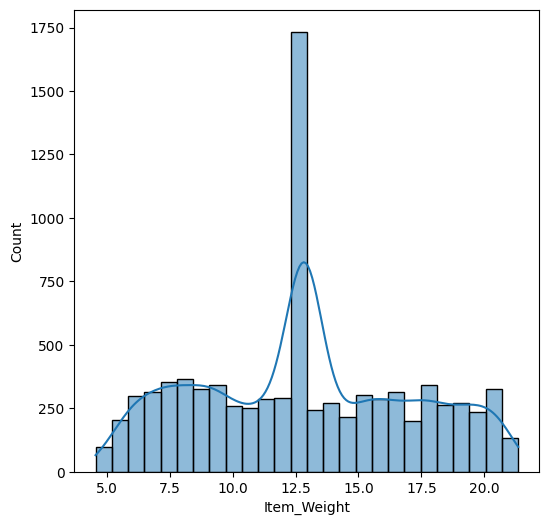

In [15]:
plt.figure(figsize=(6,6))
sns.histplot(train["Item_Weight"],kde=True)
plt.show()

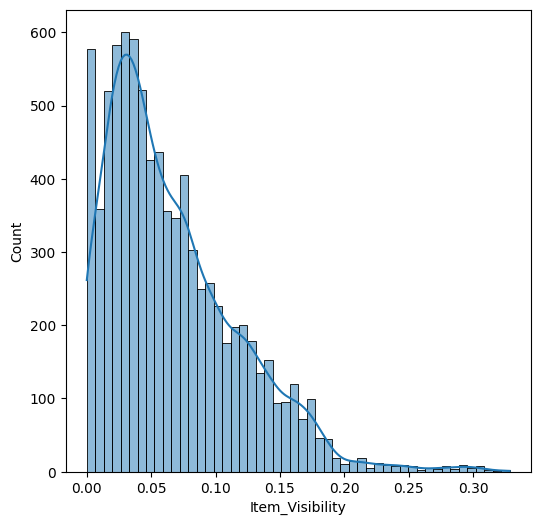

In [16]:
plt.figure(figsize=(6,6))
sns.histplot(train["Item_Visibility"],kde=True)
plt.show()

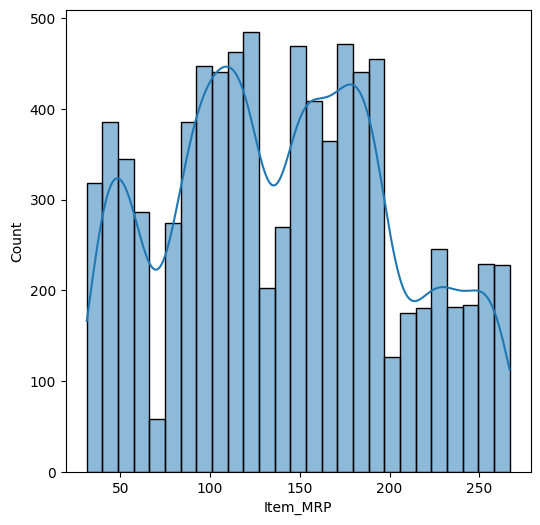

In [17]:
plt.figure(figsize=(6,6))
sns.histplot(train["Item_MRP"],kde=True)
plt.show()

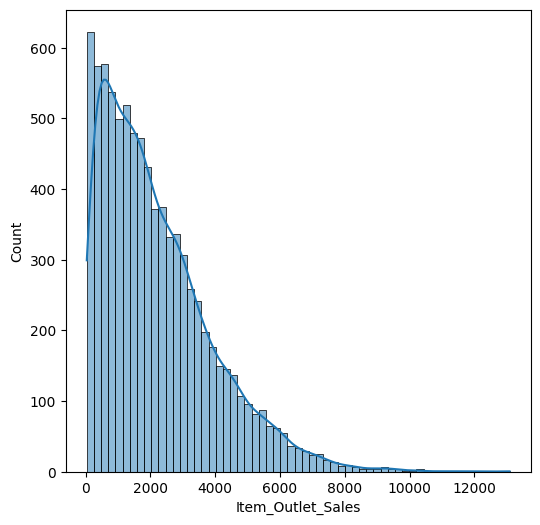

In [18]:
plt.figure(figsize=(6,6))
sns.histplot(train["Item_Outlet_Sales"],kde=True)
plt.show()

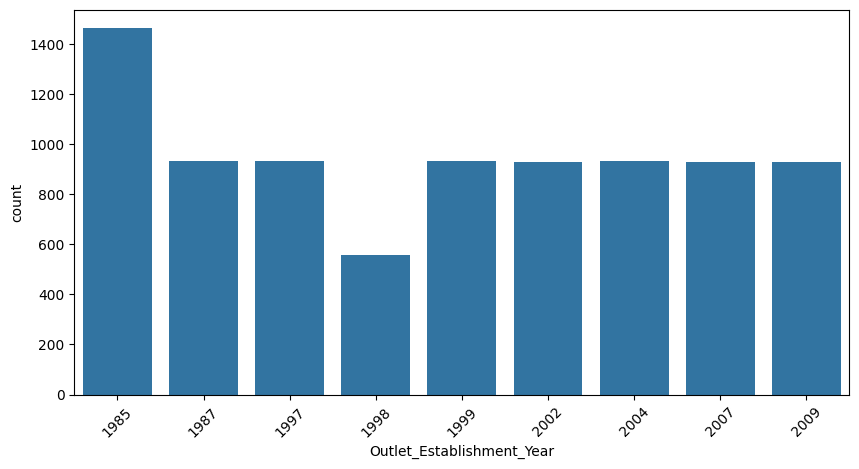

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(x="Outlet_Establishment_Year",data=train)
plt.xticks(rotation=45)
plt.show()

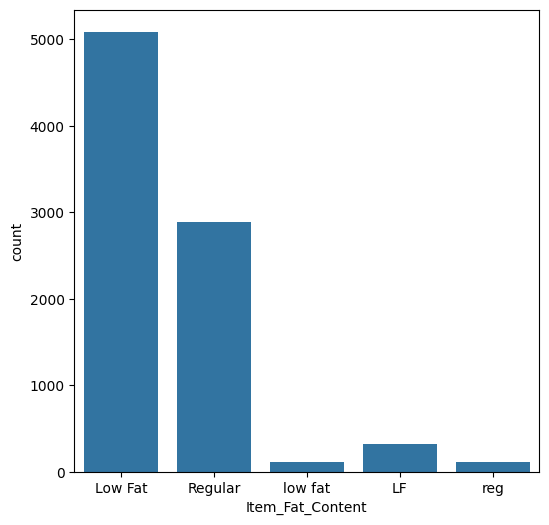

In [20]:
plt.figure(figsize=(6,6))
sns.countplot(x="Item_Fat_Content",data=train)
plt.show()

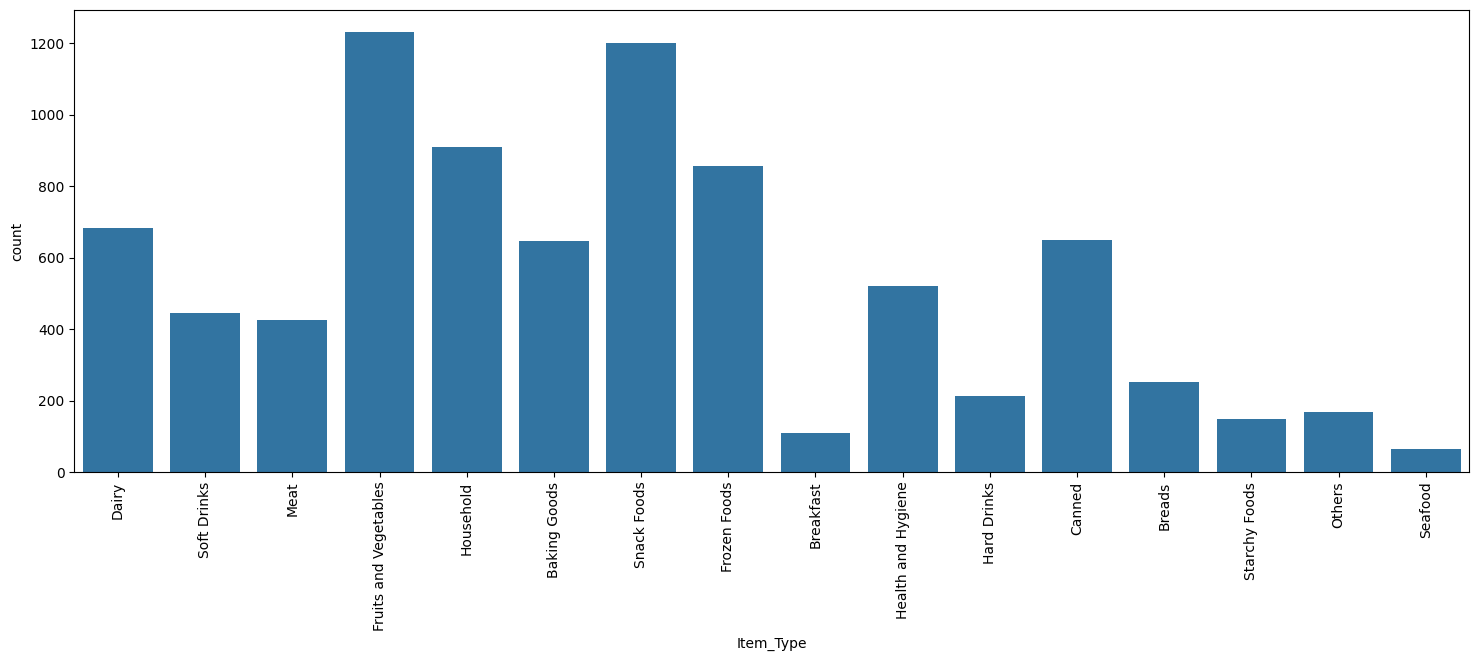

In [21]:
plt.figure(figsize=(18,6))
sns.countplot(x="Item_Type",data=train)
plt.xticks(rotation=90)
plt.show()

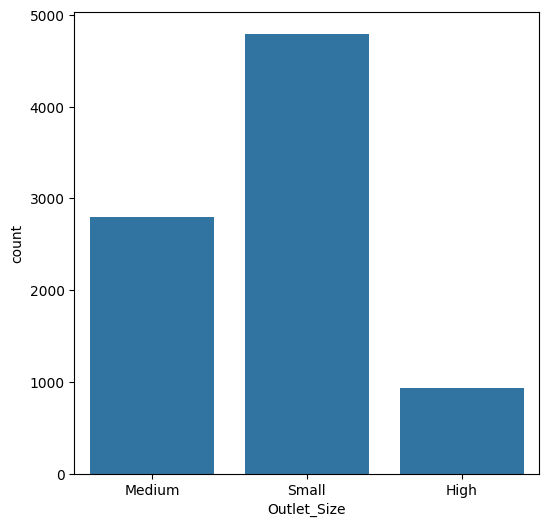

In [22]:
plt.figure(figsize=(6,6))
sns.countplot(x="Outlet_Size",data=train)
plt.show()

In [23]:
train["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [24]:
train.replace({
    "Item_Fat_Content":{
        "low fat":"Low Fat",
        "LF":"Low Fat",
        "reg":"Regular"
    }
},inplace=True)

In [25]:
train["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [26]:
encoder = LabelEncoder()

In [27]:
cat_cols = [
    "Item_Identifier",
    "Item_Fat_Content",
    "Item_Type",
    "Outlet_Identifier",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type"
]

In [28]:
for col in cat_cols:
    train[col] = encoder.fit_transform(train[col])

In [29]:
X = train.drop("Item_Outlet_Sales",axis=1)

Y = train["Item_Outlet_Sales"]

In [30]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [31]:
print(X_train.shape)
print(X_test.shape)

(6818, 11)
(1705, 11)


In [32]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [33]:
model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [34]:
train_pred = model.predict(X_train)

In [35]:
print("Training R2 Score :",r2_score(Y_train,train_pred))

Training R2 Score : 0.7721025617852092


In [36]:
test_pred = model.predict(X_test)

In [37]:
print("R2 Score :",r2_score(Y_test,test_pred))

R2 Score : 0.5833095740392251


In [38]:
print("MAE :",mean_absolute_error(Y_test,test_pred))

MAE : 744.1446058550326


In [39]:
print("RMSE :",np.sqrt(mean_squared_error(Y_test,test_pred)))

RMSE : 1064.214313382017


In [40]:
test["Item_Weight"].fillna(train["Item_Weight"].mean(),inplace=True)

/tmp/ipykernel_2093/1623713569.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["Item_Weight"].fillna(train["Item_Weight"].mean(),inplace=True)


In [41]:
missing = test["Outlet_Size"].isnull()

test.loc[missing,"Outlet_Size"] = test.loc[
    missing,"Outlet_Type"
].apply(lambda x: mode[x])

In [42]:
test.replace({
    "Item_Fat_Content":{
        "low fat":"Low Fat",
        "LF":"Low Fat",
        "reg":"Regular"
    }
},inplace=True)

In [43]:
for col in cat_cols:
    test[col] = encoder.fit_transform(test[col])

In [44]:
prediction = model.predict(test)

In [45]:
submission = pd.DataFrame({
    "Item_Identifier":test["Item_Identifier"],
    "Outlet_Identifier":test["Outlet_Identifier"],
    "Item_Outlet_Sales":prediction
})

submission.head()

,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,1103,9,1309.052002
1,1067,2,1252.666992
2,1406,0,531.039612
3,809,2,2334.250732
4,1184,5,7119.447266


In [46]:
submission.to_csv("BigMart_Prediction.csv",index=False)

In [47]:
from google.colab import files

files.download("BigMart_Prediction.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>